In [7]:
from pathlib import Path
import shutil
import subprocess
import re
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [8]:
# =============================================================================
# USER SETTINGS
# =============================================================================
REFRESH_REPO = True
HORIZON = "10y"              # "10y" or "25y"
BASELINE = "broken"
LTHP_SCHEDULE = "25"     # "24" or "25" (applies only if your CSV includes both LT-ASHP schedules)
SAVE_FILE = True
figsize = (10, 3)

REPO_URL = "https://github.com/mickdeines/PGST"
PROJECT_DIR = Path.cwd() / "PGST"
INFILE = PROJECT_DIR / "results_tidy.csv"

In [9]:
# =============================================================================
# REPO / DATA SETUP
# =============================================================================
def ensure_repo(refresh: bool = False):
    if refresh and PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", "--quiet", REPO_URL, str(PROJECT_DIR)], check=True)


def set_plot_style():
    mpl.rcParams.update(
        {
            "figure.dpi": 160,
            "savefig.dpi": 300,
            "font.size": 11,
            "axes.titlesize": 18,
            "axes.labelsize": 12,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": False,
            "legend.frameon": False,
        }
    )


def apply_lthp_schedule(df: pd.DataFrame) -> pd.DataFrame:
    """Filter/normalize LT-ASHP rows to a selected electric rate schedule.

    Compatible with:
      - A dedicated schedule column (e.g., 'schedule', 'rate_schedule', 'lthp_schedule', etc.)
      - Schedule embedded in the scenario name (e.g., 'LT-ASHP (Schedule 24)')
      - Older CSVs with no schedule information (no-op)
    """
    if LTHP_SCHEDULE is None:
        return df

    wanted = str(LTHP_SCHEDULE).strip()

    scenario = df["scenario"].astype(str)
    is_lt = (
        scenario.str.contains(r"\bLT[- ]?ASHP\b", case=False, regex=True, na=False)
        | scenario.str.contains(r"\bLTHP\b", case=False, regex=True, na=False)
    )
    if not bool(is_lt.any()):
        return df

    schedule_cols = [
        "lthp_schedule",
        "schedule",
        "rate_schedule",
        "electric_schedule",
        "tariff_schedule",
        "utility_schedule",
    ]
    for col in schedule_cols:
        if col in df.columns:
            sch = df[col].astype(str).str.extract(r"(\d+)", expand=False)
            keep = (~is_lt) | (sch == wanted) | sch.isna()
            out = df.loc[keep].copy()
            out.loc[is_lt & keep, "scenario"] = "LT-ASHP"
            return out.drop(columns=[col])

    extracted = scenario.str.extract(r"(?:Schedule|Sched)\s*(\d+)", flags=re.IGNORECASE, expand=False)
    if extracted.notna().any():
        keep = (~is_lt) | (extracted == wanted) | extracted.isna()
        out = df.loc[keep].copy()
        out.loc[is_lt & keep, "scenario"] = "LT-ASHP"
        return out

    return df


def load_data() -> pd.DataFrame:
    ensure_repo(refresh=REFRESH_REPO)
    set_plot_style()

    df = pd.read_csv(INFILE)
    required = {
        "horizon",
        "scenario",
        "pv_case",
        "capex_total",
        "opex_total",
        "lcc_total",
        "baseline",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in input CSV: {sorted(missing)}")

    for col in ["horizon", "scenario", "pv_case", "baseline"]:
        df[col] = df[col].astype(str)
    for col in [
        "capex_total", "opex_total", "lcc_total",
        "capex_equipment", "capex_installation", "capex_distribution", "capex_pv"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = apply_lthp_schedule(df)

    return df

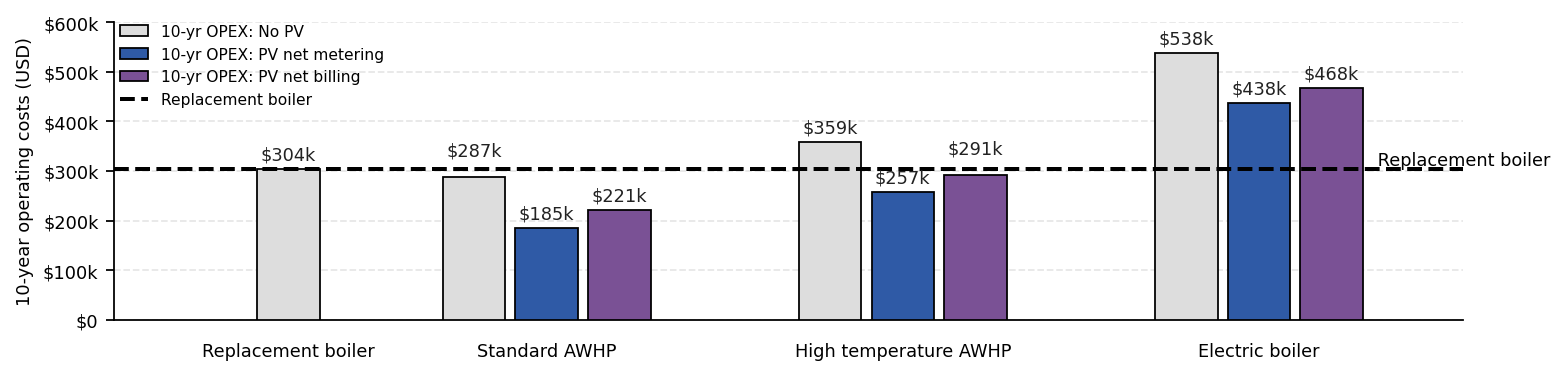

In [10]:
# =============================================================================
# PLOT CONFIG
# =============================================================================
SCENARIO_ORDER_SUPER = [
    ("Fixed controls", "no_pv"),
    ("LT-ASHP", "no_pv"),
    ("LT-ASHP", "net_metering"),
    ("LT-ASHP", "net_billing"),
    ("HT-ASHP", "no_pv"),
    ("HT-ASHP", "net_metering"),
    ("HT-ASHP", "net_billing"),
    ("Electric Boiler", "no_pv"),
    ("Electric Boiler", "net_metering"),
    ("Electric Boiler", "net_billing"),
]

GROUP_LAYOUT = [
    {"scenario": "Fixed controls", "pv_cases": ["no_pv"]},
    {"scenario": "LT-ASHP", "pv_cases": ["no_pv", "net_metering", "net_billing"]},
    {"scenario": "HT-ASHP", "pv_cases": ["no_pv", "net_metering", "net_billing"]},
    {"scenario": "Electric Boiler", "pv_cases": ["no_pv", "net_metering", "net_billing"]},
]

SCENARIO_LABELS = {
    "Fixed controls": "Replacement boiler",
    "LT-ASHP": "Standard AWHP",
    "HT-ASHP": "High temperature AWHP",
    "Electric Boiler": "Electric boiler",
}

POSTER_PV_FILL_COLORS = {
    "no_pv": "#DDDDDD",
    "net_metering": "#2F5AA6",
    "net_billing": "#7A5195",
}

CAPEX_COMPONENT_COLORS = {
    "heating": "#8B8B8B",
    "pv": "#FFD700",
}


def money(x: float) -> str:
    ax = abs(x)
    if ax >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    if ax >= 1_000:
        return f"${x/1_000:.0f}k"
    return f"${x:.0f}"


HORIZON_CFG = {
    "25y": {
        "outdir": PROJECT_DIR / "out_client_25y",
        "opex_label": "25y OPEX",
        "poster": {
            "title_size": 0,
            "label_size": 8,
            "tick_size": 8,
            "annot_size": 8,
            "legend_size": 7,
            "figsize": figsize,
            "ylim_top": 2_000_000,
            "draw_capex_bar": True,
            "ylabel": "Life-cycle cost (USD)",
            "title": "25-Year Life-Cycle Cost Comparison Across Electrification Scenarios",
            "status_color": "#000000",
            "legend_handles": lambda cfg: [
                Patch(facecolor=CAPEX_COMPONENT_COLORS["heating"], edgecolor="black", linewidth=0.8, label="Heating equipment CAPEX"),
                Patch(facecolor=CAPEX_COMPONENT_COLORS["pv"], edgecolor="black", linewidth=0.8, label="PV system CAPEX"),
                Patch(facecolor=POSTER_PV_FILL_COLORS["no_pv"], edgecolor="black", linewidth=0.8, label="25-yr OPEX: No PV"),
                Patch(
                    facecolor=POSTER_PV_FILL_COLORS["net_metering"],
                    edgecolor="black",
                    linewidth=0.8,
                    label="25-yr OPEX: PV net metering",
                ),
                Patch(
                    facecolor=POSTER_PV_FILL_COLORS["net_billing"],
                    edgecolor="black",
                    linewidth=0.8,
                    label="25-yr OPEX: PV net billing",
                ),
                Line2D([0, 1], [0, 0], color=cfg["status_color"], linestyle="--", linewidth=1.8, label="Replacement boiler"),
            ],
            "label_offset_fn": lambda t: 0.01 * 2_000_000 + (0.02 * 2_000_000 if 870_000 <= t <= 880_000 else 0),
        },
    },
    "10y": {
        "outdir": PROJECT_DIR / "out_client_10y",
        "opex_label": "10y OPEX",
        "poster": {
            "title_size": 0,
            "label_size": 8,
            "tick_size": 8,
            "annot_size": 8,
            "legend_size": 7,
            "figsize": figsize,
            "ylim_top": 600_000,
            "draw_capex_bar": False,
            "ylabel": "10-year operating costs (USD)",
            "title": "10-Year Operating Cost Comparison Across Electrification Scenarios",
            "status_color": "#000000",
            "legend_handles": lambda cfg: [
                Patch(facecolor=POSTER_PV_FILL_COLORS["no_pv"], edgecolor="black", linewidth=0.8, label="10-yr OPEX: No PV"),
                Patch(facecolor=POSTER_PV_FILL_COLORS["net_metering"], edgecolor="black", linewidth=0.8, label="10-yr OPEX: PV net metering"),
                Patch(facecolor=POSTER_PV_FILL_COLORS["net_billing"], edgecolor="black", linewidth=0.8, label="10-yr OPEX: PV net billing"),
                Line2D([0, 1], [0, 0], color=cfg["status_color"], linestyle="--", linewidth=1.8, label="Replacement boiler"),
            ],
            "label_offset_fn": lambda t: 0.018 * 600_000 + (0.04 * 600_000 if 286_000 <= t <= 292_000 else 0),
        },
    },
}


# =============================================================================
# FINAL PLOT ONLY
# =============================================================================
def style_poster_axes(ax, cfg):
    if cfg["title_size"] > 0:
        ax.set_title(cfg["title"], fontsize=cfg["title_size"], fontweight="bold", pad=12)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_size"])
    ax.tick_params(axis="x", labelsize=cfg["tick_size"], length=0, pad=10)
    ax.tick_params(axis="y", labelsize=cfg["tick_size"])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: money(v)))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.30, zorder=0)


def plot_poster_super_costs(df: pd.DataFrame, horizon: str = HORIZON, save_file: bool = SAVE_FILE):
    horizon_cfg = HORIZON_CFG[horizon]
    cfg = horizon_cfg["poster"]

    d = df[df["horizon"] == horizon].copy()
    if d.empty:
        raise ValueError(f"No rows found for horizon={horizon}.")

    order_df = pd.DataFrame(SCENARIO_ORDER_SUPER, columns=["scenario", "pv_case"])
    d = order_df.merge(d, on=["scenario", "pv_case"], how="left")

    if d[["capex_total", "opex_total", "lcc_total"]].isna().any().any():
        missing_rows = d[d[["capex_total", "opex_total", "lcc_total"]].isna().any(axis=1)][["scenario", "pv_case"]]
        raise ValueError(
            "Missing data for one or more required scenario/PV combinations:\n" + missing_rows.to_string(index=False)
        )

    x_positions = []
    bar_scenarios = []
    bar_pv_cases = []
    group_centers = []
    current_x = 0.0
    within_group_step = 1.00
    between_group_gap = 1.90
    extra_gap_after_broken = 0.50
    extra_gap_after_fixed = -0.35
    bar_width = 0.86

    for group in GROUP_LAYOUT:
        start_x = current_x
        for pv_case in group["pv_cases"]:
            x_positions.append(current_x)
            bar_scenarios.append(group["scenario"])
            bar_pv_cases.append(pv_case)
            current_x += within_group_step
        end_x = x_positions[-1]
        group_centers.append((start_x + end_x) / 2)

        extra_gap = 0.0
        if group["scenario"] == "Broken controls":
            extra_gap = extra_gap_after_broken
        elif group["scenario"] == "Fixed controls":
            extra_gap = extra_gap_after_fixed

        current_x += between_group_gap + extra_gap

    layout_df = pd.DataFrame({"scenario": bar_scenarios, "pv_case": bar_pv_cases, "x": x_positions})
    d = layout_df.merge(d, on=["scenario", "pv_case"], how="left")

    # Combine equipment + installation + distribution into one "heating capex" column
    d["capex_heating"] = (
        d["capex_equipment"].fillna(0) +
        d["capex_installation"].fillna(0) +
        d["capex_distribution"].fillna(0)
    )
    d["capex_pv"] = d["capex_pv"].fillna(0)

    capex_heating = d["capex_heating"].to_numpy()
    capex_pv = d["capex_pv"].to_numpy()
    opex = d["opex_total"].to_numpy()
    total = d["lcc_total"].to_numpy()
    x = d["x"].to_numpy()

    fig, ax = plt.subplots(figsize=cfg["figsize"])
    fig.patch.set_facecolor("white")

    if cfg["draw_capex_bar"]:
        # Heating equipment CAPEX (equipment + installation + distribution)
        ax.bar(
            x,
            capex_heating,
            width=bar_width,
            color=CAPEX_COMPONENT_COLORS["heating"],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

        # PV system CAPEX
        ax.bar(
            x,
            capex_pv,
            width=bar_width,
            bottom=capex_heating,
            color=CAPEX_COMPONENT_COLORS["pv"],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )
        # --- PV (yellow) annotations centered on the yellow segment ---
        for i in range(len(x)):
            if capex_pv[i] <= 0:
                continue
            if d.loc[i, "scenario"] == "LT-ASHP" and d.loc[i, "pv_case"] == "net_billing":
                note = "(i)"
            elif d.loc[i, "scenario"] == "HT-ASHP" and d.loc[i, "pv_case"] == "net_billing":
                note = "(ii)"
            elif d.loc[i, "pv_case"] in ("net_metering", "net_billing"):
                note = "(iii)"
            else:
                continue

            ax.text(
                x[i],
                capex_heating[i] + 0.5 * capex_pv[i],
                note,
                ha="center",
                va="center",
                fontsize=7.4,
                color="#000000",
                zorder=7,
            )
    ax.bar(
        x,
        opex,
        width=bar_width,
        bottom=capex_heating + capex_pv if cfg["draw_capex_bar"] else None,
        color=[POSTER_PV_FILL_COLORS.get(pv, "#999999") for pv in d["pv_case"]],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        label=horizon_cfg["opex_label"],
    )

    status_mask = (
        (d["scenario"] == "Fixed controls")
        & (d["pv_case"] == "no_pv")
    )

    if status_mask.sum() == 1:
        status_val = float(d.loc[status_mask, "lcc_total"].iloc[0])

        ax.axhline(
            status_val,
            color=cfg["status_color"],
            linewidth=1.8,
            linestyle="--",
            alpha=1.0,
            zorder=6,
        )

        ax.text(
            x.max() + 0.55,
            status_val,
            " Replacement boiler",
            ha="left",
            va="bottom",
            fontsize=cfg["tick_size"],
            color=cfg["status_color"],
            zorder=7,
        )

    ax.set_ylim(0, cfg["ylim_top"])
    for i, t in enumerate(total):
        ax.text(
            x[i],
            t + cfg["label_offset_fn"](t),
            money(t),
            ha="center",
            va="bottom",
            fontsize=cfg["annot_size"],
            color="#222222",
            rotation=0,
            zorder=7,
        )

    ax.set_xticks(group_centers)
    ax.set_xticklabels([SCENARIO_LABELS.get(g["scenario"], g["scenario"]) for g in GROUP_LAYOUT])
    ax.set_xlim(x.min() - 2.4, x.max() + 1.8)
    style_poster_axes(ax, cfg)

    ax.legend(
        handles=cfg["legend_handles"](cfg),
        fontsize=cfg["legend_size"],
        ncol=1,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.015),
        frameon=False,
        columnspacing=1.6,
        handlelength=1.8,
        borderaxespad=0.0,
    )

    plt.tight_layout(pad=1.2)
    plt.subplots_adjust(top=0.80, bottom=0.18)

    if save_file:
        outpath = horizon_cfg["outdir"] / f"poster_super_costs_{horizon}.png"
        outpath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outpath, bbox_inches="tight")

    plt.show()


# =============================================================================
# RUN
# =============================================================================
df_all = load_data()
plot_poster_super_costs(df_all, horizon=HORIZON, save_file=SAVE_FILE)

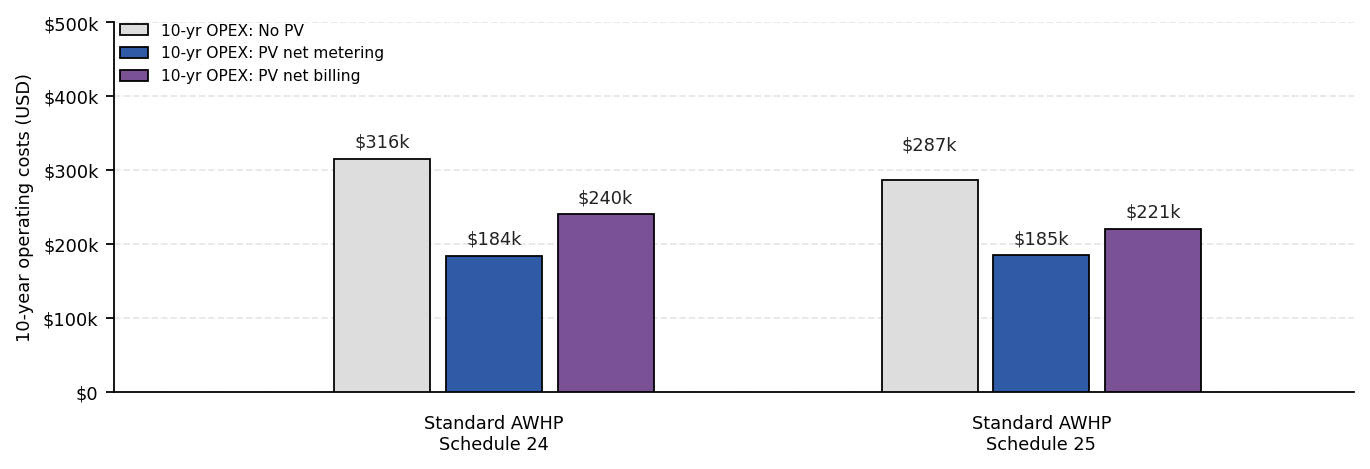

In [11]:
# =============================================================================
# LT-ASHP SCHEDULE COMPARISON PLOT
# =============================================================================

def plot_lthp_schedule_comparison(df: pd.DataFrame, horizon: str = HORIZON, save_file: bool = SAVE_FILE):
    """Compare LT-ASHP Schedule 24 vs Schedule 25 across all PV cases.

    Requires lthp_schedule column in the dataframe (not filtered by LTHP_SCHEDULE).
    """
    horizon_cfg = HORIZON_CFG[horizon]
    cfg = horizon_cfg["poster"]

    # Do NOT filter by LTHP_SCHEDULE here; we need both 24 and 25
    d = df[df["horizon"] == horizon].copy()

    # Keep only LT-ASHP rows
    d = d[d["scenario"].str.contains(r"\bLT[- ]?ASHP\b", case=False, regex=True, na=False)].copy()

    if d.empty:
        raise ValueError(f"No LT-ASHP rows found for horizon={horizon}.")

    # Extract schedule from lthp_schedule column, handling NaN properly
    if "lthp_schedule" not in d.columns:
        raise ValueError("Missing lthp_schedule column in dataframe.")

    # Convert to string and extract just the numeric schedule, dropna handles NaN
    d["schedule"] = pd.to_numeric(d["lthp_schedule"], errors="coerce").astype(str).str.replace(".0", "", regex=False)

    # Keep only schedules 24 and 25 (filter out 'nan' strings)
    d = d[d["schedule"].isin(["24", "25"])].copy()

    if d.empty:
        raise ValueError(f"No LT-ASHP Schedule 24/25 data found for horizon={horizon}.")

    # Define order: Schedule 24, Schedule 25, each with 3 PV cases
    SCHEDULE_ORDER = [
        ("24", "no_pv"),
        ("24", "net_metering"),
        ("24", "net_billing"),
        ("25", "no_pv"),
        ("25", "net_metering"),
        ("25", "net_billing"),
    ]

    SCHEDULE_GROUP_LAYOUT = [
        {"schedule": "24", "pv_cases": ["no_pv", "net_metering", "net_billing"]},
        {"schedule": "25", "pv_cases": ["no_pv", "net_metering", "net_billing"]},
    ]

    SCHEDULE_LABELS = {
        "24": "Standard AWHP\nSchedule 24",
        "25": "Standard AWHP\nSchedule 25",
    }

    # Merge to desired order
    order_df = pd.DataFrame(SCHEDULE_ORDER, columns=["schedule", "pv_case"])
    d = order_df.merge(d, on=["schedule", "pv_case"], how="left")

    if d[["capex_total", "opex_total", "lcc_total"]].isna().any().any():
        missing_rows = d[d[["capex_total", "opex_total", "lcc_total"]].isna().any(axis=1)][["schedule", "pv_case"]]
        raise ValueError(
            "Missing data for one or more Schedule/PV combinations:\n" + missing_rows.to_string(index=False)
        )

    # Layout positions
    x_positions = []
    bar_schedules = []
    bar_pv_cases = []
    group_centers = []
    current_x = 0.0
    within_group_step = 1.00
    between_group_gap = 1.90
    bar_width = 0.86

    for group in SCHEDULE_GROUP_LAYOUT:
        start_x = current_x
        for pv_case in group["pv_cases"]:
            x_positions.append(current_x)
            bar_schedules.append(group["schedule"])
            bar_pv_cases.append(pv_case)
            current_x += within_group_step
        end_x = x_positions[-1]
        group_centers.append((start_x + end_x) / 2)
        current_x += between_group_gap

    layout_df = pd.DataFrame({"schedule": bar_schedules, "pv_case": bar_pv_cases, "x": x_positions})
    d = layout_df.merge(d, on=["schedule", "pv_case"], how="left")

    # Combine CAPEX components
    d["capex_heating"] = (
        d["capex_equipment"].fillna(0) +
        d["capex_installation"].fillna(0) +
        d["capex_distribution"].fillna(0)
    )
    d["capex_pv"] = d["capex_pv"].fillna(0)

    capex_heating = d["capex_heating"].to_numpy()
    capex_pv = d["capex_pv"].to_numpy()
    opex = d["opex_total"].to_numpy()
    total = d["lcc_total"].to_numpy()
    x = d["x"].to_numpy()

    fig, ax = plt.subplots(figsize=cfg["figsize"])
    fig.patch.set_facecolor("white")

    if cfg["draw_capex_bar"]:
        # Heating equipment CAPEX
        ax.bar(
            x,
            capex_heating,
            width=bar_width,
            color=CAPEX_COMPONENT_COLORS["heating"],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

        # PV system CAPEX
        ax.bar(
            x,
            capex_pv,
            width=bar_width,
            bottom=capex_heating,
            color=CAPEX_COMPONENT_COLORS["pv"],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

    ax.bar(
        x,
        opex,
        width=bar_width,
        bottom=capex_heating + capex_pv if cfg["draw_capex_bar"] else None,
        color=[POSTER_PV_FILL_COLORS.get(pv, "#999999") for pv in d["pv_case"]],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    ax.set_ylim(0, 5e5)
    for i, t in enumerate(total):
        ax.text(
            x[i],
            t + cfg["label_offset_fn"](t),
            money(t),
            ha="center",
            va="bottom",
            fontsize=cfg["annot_size"],
            color="#222222",
            rotation=0,
            zorder=7,
        )

    ax.set_xticks(group_centers)
    ax.set_xticklabels([SCHEDULE_LABELS.get(g["schedule"], g["schedule"]) for g in SCHEDULE_GROUP_LAYOUT])
    ax.set_xlim(x.min() - 2.4, x.max() + 1.8)

    # Update title for this plot
    title_override = "LT-AWHP: Schedule 24 vs. Schedule 25 Comparison" if cfg["title_size"] > 0 else ""
    style_poster_axes(ax, cfg)
    if title_override:
        ax.set_title(title_override, fontsize=cfg["title_size"], fontweight="bold", pad=12)

    legend_handles = [h for h in cfg["legend_handles"](cfg) if not isinstance(h, Line2D)]


    ax.legend(
        handles=legend_handles,
        fontsize=cfg["legend_size"],
        ncol=1,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.015),
        frameon=False,
        columnspacing=1.6,
        handlelength=1.8,
        borderaxespad=0.0,
    )

    if save_file:
        outpath = horizon_cfg["outdir"] / f"lthp_schedule_comparison_{horizon}.png"
        outpath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outpath, bbox_inches="tight")

    plt.show()


# =============================================================================
# CALL THE COMPARISON PLOT
# =============================================================================
df_all_schedules = pd.read_csv(INFILE)
for col in ["horizon", "scenario", "pv_case"]:
    df_all_schedules[col] = df_all_schedules[col].astype(str)
for col in [
    "capex_total", "opex_total", "lcc_total",
    "capex_equipment", "capex_installation", "capex_distribution", "capex_pv"
]:
    if col in df_all_schedules.columns:
        df_all_schedules[col] = pd.to_numeric(df_all_schedules[col], errors="coerce")

plot_lthp_schedule_comparison(df_all_schedules, horizon=HORIZON, save_file=SAVE_FILE)


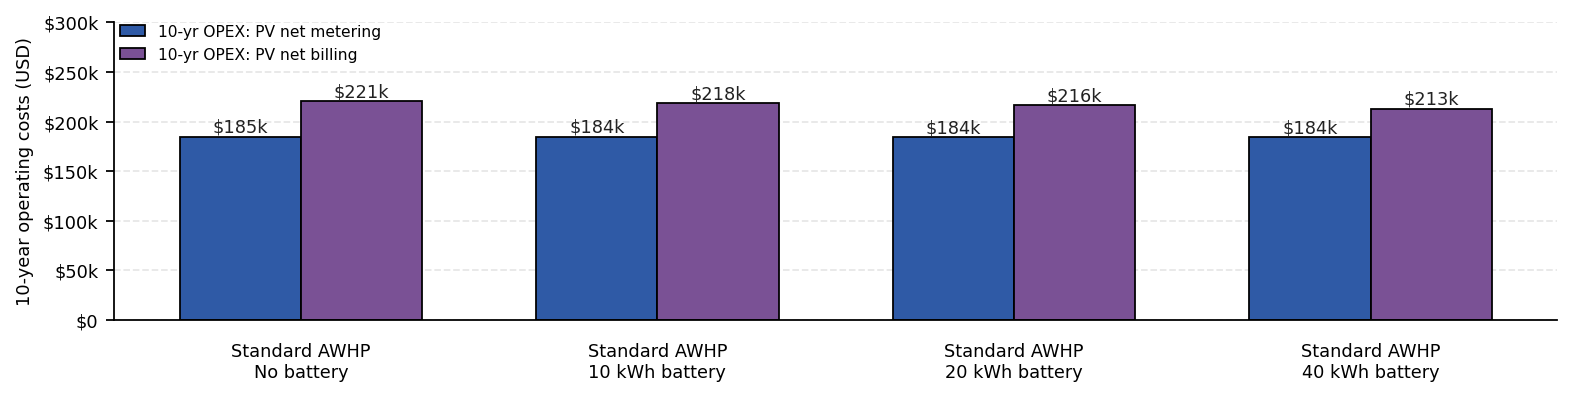

In [12]:
def plot_battery_lcc(df: pd.DataFrame, save_file=SAVE_FILE):
    set_plot_style()

    nm_color = POSTER_PV_FILL_COLORS["net_metering"]
    nb_color = POSTER_PV_FILL_COLORS["net_billing"]

    BATTERY_DELTAS = {
        "25y": {
            "nm": [41_845, 52_457, 73_716],
            "nb": [36_059, 41_437, 52_785],
        },
        "10y": {
            "nm": [-268, -313, -391],
            "nb": [-2_253, -4_064, -7_458],
        },
    }

    BATTERY_CAPEX = {
        "No battery": 0,
        "10 kWh": 30_428,
        "20 kWh": 38_089,
        "40 kWh": 53_410,
    }

    NB_PV_CAPEX = {
        "No battery": None,
        "10 kWh": 128_377,
        "20 kWh": 135_747,
        "40 kWh": 151_969,
    }

    horizon_cfg = HORIZON_CFG[HORIZON]
    pcfg = horizon_cfg["poster"]
    deltas = BATTERY_DELTAS[HORIZON]

    d = df[df["horizon"] == HORIZON]

    # ------------------------------------------------------------------
    # Base values
    # ------------------------------------------------------------------
    base_nm = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_metering"),
            "lcc_total",
        ].iloc[0]
    )

    base_nb = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_billing"),
            "lcc_total",
        ].iloc[0]
    )

    nm_vals = [base_nm] + [base_nm + delta for delta in deltas["nm"]]
    nb_vals = [base_nb] + [base_nb + delta for delta in deltas["nb"]]

    heat_nm = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_metering"),
            [
                "capex_equipment",
                "capex_installation",
                "capex_distribution",
            ],
        ]
        .sum(axis=1)
        .iloc[0]
    )

    heat_nb = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_billing"),
            [
                "capex_equipment",
                "capex_installation",
                "capex_distribution",
            ],
        ]
        .sum(axis=1)
        .iloc[0]
    )

    pv_nm_base = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_metering"),
            "capex_pv",
        ].iloc[0]
    )

    pv_nb_base = float(
        d.loc[
            (d["scenario"] == "LT-ASHP")
            & (d["pv_case"] == "net_billing"),
            "capex_pv",
        ].iloc[0]
    )

    labels = ["Standard AWHP\nNo battery", "Standard AWHP\n10 kWh battery", "Standard AWHP\n20 kWh battery", "Standard AWHP\n40 kWh battery"]
    battery_cases = ["No battery", "10 kWh", "20 kWh", "40 kWh"]
    x = np.arange(len(labels))
    width = 0.34

    fig, ax = plt.subplots(figsize=pcfg["figsize"])
    fig.patch.set_facecolor("white")

    # ==================================================================
    # 25-YEAR VERSION (stacked CAPEX/OPEX)
    # ==================================================================
    if HORIZON == "25y":

        batt_capex = [BATTERY_CAPEX[l] for l in battery_cases]

        pv_nm = [pv_nm_base] * 4

        pv_nb = [
            pv_nb_base,
            NB_PV_CAPEX["10 kWh"],
            NB_PV_CAPEX["20 kWh"],
            NB_PV_CAPEX["40 kWh"],
        ]

        opex_nm = [
            total - heat_nm - pv - batt
            for total, pv, batt in zip(nm_vals, pv_nm, batt_capex)
        ]

        opex_nb = [
            total - heat_nb - pv - batt
            for total, pv, batt in zip(nb_vals, pv_nb, batt_capex)
        ]

        # Net metering
        ax.bar(
            x - width / 2,
            [heat_nm] * 4,
            width=width,
            color=CAPEX_COMPONENT_COLORS["heating"],
            edgecolor="black",
            linewidth=0.8,
        )

        ax.bar(
            x - width / 2,
            pv_nm,
            width=width,
            bottom=[heat_nm] * 4,
            color=CAPEX_COMPONENT_COLORS["pv"],
            edgecolor="black",
            linewidth=0.8,
        )

        ax.bar(
            x - width / 2,
            batt_capex,
            width=width,
            bottom=np.array([heat_nm] * 4) + np.array(pv_nm),
            color="#B8A6D9",
            edgecolor="black",
            linewidth=0.8,
        )

        bars_nm = ax.bar(
            x - width / 2,
            opex_nm,
            width=width,
            bottom=(
                np.array([heat_nm] * 4)
                + np.array(pv_nm)
                + np.array(batt_capex)
            ),
            color=nm_color,
            edgecolor="black",
            linewidth=0.8,
        )

        # Net billing
        ax.bar(
            x + width / 2,
            [heat_nb] * 4,
            width=width,
            color=CAPEX_COMPONENT_COLORS["heating"],
            edgecolor="black",
            linewidth=0.8,
        )

        ax.bar(
            x + width / 2,
            pv_nb,
            width=width,
            bottom=[heat_nb] * 4,
            color=CAPEX_COMPONENT_COLORS["pv"],
            edgecolor="black",
            linewidth=0.8,
        )

        ax.bar(
            x + width / 2,
            batt_capex,
            width=width,
            bottom=np.array([heat_nb] * 4) + np.array(pv_nb),
            color="#B8A6D9",
            edgecolor="black",
            linewidth=0.8,
        )

        bars_nb = ax.bar(
            x + width / 2,
            opex_nb,
            width=width,
            bottom=(
                np.array([heat_nb] * 4)
                + np.array(pv_nb)
                + np.array(batt_capex)
            ),
            color=nb_color,
            edgecolor="black",
            linewidth=0.8,
        )
        # --------------------------------------------------------------
        # Battery/PV annotations
        # --------------------------------------------------------------

        # Net metering:
        # No battery, 10, 20, 40 kWh -> all "(v)"
        for i in range(4):

            batt = batt_capex[i]

            y_nm = heat_nm + 0.5 * pv_nm[i]

            ax.text(
                x[i] - width / 2,
                y_nm,
                "(v)",
                ha="center",
                va="center",
                fontsize=7.4,
                color="#000000",
                zorder=7,
            )

        # Net billing:
        # No battery -> (i)
        # 10 kWh     -> (ii)
        # 20 kWh     -> (iii)
        # 40 kWh     -> (iv)

        nb_notes = ["(i)", "(ii)", "(iii)", "(iv)"]

        for i, note in enumerate(nb_notes):

            batt = batt_capex[i]

            y_nb = heat_nb + 0.5 * pv_nb[i]

            ax.text(
                x[i] + width / 2,
                y_nb,
                note,
                ha="center",
                va="center",
                fontsize=7.4,
                color="#000000",
                zorder=7,
            )
        legend_handles = [
            Patch(
                facecolor=CAPEX_COMPONENT_COLORS["heating"],
                edgecolor="black",
                linewidth=0.8,
                label="Heating equipment CAPEX",
            ),
            Patch(
                facecolor=CAPEX_COMPONENT_COLORS["pv"],
                edgecolor="black",
                linewidth=0.8,
                label="PV system CAPEX",
            ),
            Patch(
                facecolor="#B8A6D9",
                edgecolor="black",
                linewidth=0.8,
                label="Battery CAPEX",
            ),
            Patch(
                facecolor=nm_color,
                edgecolor="black",
                linewidth=0.8,
                label="25-yr OPEX: PV net metering",
            ),
            Patch(
                facecolor=nb_color,
                edgecolor="black",
                linewidth=0.8,
                label="25-yr OPEX: PV net billing",
            ),
        ]

        ax.set_ylim(0, 1_800_000)

    # ==================================================================
    # 10-YEAR VERSION (OPEX ONLY)
    # ==================================================================
    else:

        bars_nm = ax.bar(
            x - width / 2,
            nm_vals,
            width=width,
            color=nm_color,
            edgecolor="black",
            linewidth=0.8,
        )

        bars_nb = ax.bar(
            x + width / 2,
            nb_vals,
            width=width,
            color=nb_color,
            edgecolor="black",
            linewidth=0.8,
        )

        legend_handles = [
            Patch(
                facecolor=nm_color,
                edgecolor="black",
                linewidth=0.8,
                label="10-yr OPEX: PV net metering",
            ),
            Patch(
                facecolor=nb_color,
                edgecolor="black",
                linewidth=0.8,
                label="10-yr OPEX: PV net billing",
            ),
        ]

        ax.set_ylim(0, 300_000)

    # ==================================================================
    # Labels
    # ==================================================================
    ymax = max(nm_vals + nb_vals)
    ymin = min(nm_vals + nb_vals)

    for bars, vals in [(bars_nm, nm_vals), (bars_nb, nb_vals)]:
        for bar, h in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + (ymax - ymin) * 0.02,
                money(h),
                ha="center",
                va="bottom",
                fontsize=pcfg["annot_size"],
                color="#222222",
                zorder=5,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=pcfg["tick_size"])
    ax.tick_params(axis="x", length=0, pad=8)

    style_poster_axes(ax, {**pcfg, "ylabel": pcfg["ylabel"]})

    ax.legend(
        handles=legend_handles,
        fontsize=pcfg["legend_size"],
        ncol=1,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.015),
        frameon=False,
        handlelength=1.6,
        borderaxespad=0.0,
    )

    plt.tight_layout(pad=1.2)
    plt.subplots_adjust(top=0.80, bottom=0.18)

    if save_file:
        outdir = horizon_cfg["outdir"]
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            outdir / f"battery_lcc_{HORIZON}.png",
            bbox_inches="tight",
            dpi=300,
        )

    plt.show()


plot_battery_lcc(df_all, save_file=SAVE_FILE)